# Assignment 3

## General information

**Instructions:**

- Provide brief (2-3 sentence) interpretations/explanations for your answers - don't just include code and outputs.
- You may use AI tools, but you must take full responsibility for everything in your submission.
- Be concise and focused: include what's necessary to support your arguments rather than listing every step. We take this seriously and will penalize excessive verbosity.
- Submit only the converted PDF file to Moodle.

Grades will be distributed with the following rule: from the points you earn, you get 100% if you submit until the due date (**2026-03-25 12:00 CET**), 50% within 24 hours past due date, and 0% after that.

## Task 1: Dense Neural Networks on Fashion-MNIST (6 points)

Take the alternative version of the famous MNIST dataset, which consists of images of Zalando's articles. Your task is to correctly classify the images into one of the ten categories, such as dress or shirt. The images are in exactly the same format as we saw for the handwritten digits: 28x28 pixel grayscale images.

In class we saw that regularization had modest effects on MNIST because it is a relatively easy dataset. Fashion-MNIST is harder so you should see more dramatic differences between model architectures and regularization strategies.

In [119]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import tensorflow as tf

# Load Fashion-MNIST
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Take the first 30k images from the train set to speed up training
# // You can change this number if you want: further decrease if your machine suffers, or increase if you have a powerful machine)
# // You can even try Google Colab, which provides free access to powerful GPUs (https://colab.research.google.com/)
X_train_sample = X_train_full[:30000]
y_train_sample = y_train_full[:30000]

# Split training into train and validation sets (90/10)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_sample, y_train_sample,
    test_size=0.1, random_state=20260318, stratify=y_train_sample
)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")
print(f"Pixel range:    [{X_train.min()}, {X_train.max()}]")
print(f"\nSamples per class (train): {np.bincount(y_train)}")

Training set:   (27000, 28, 28)
Validation set: (3000, 28, 28)
Test set:       (10000, 28, 28)
Pixel range:    [0, 255]

Samples per class (train): [2651 2713 2690 2715 2664 2727 2773 2719 2675 2673]


<div style="page-break-after: always"></div>

### Questions

1. What would be an appropriate metric to evaluate your models? Why? (*Hint*: Look at the class distribution above. No code required.)

2. Show some example images from the data (at least one per class). What do you notice about the visual similarity between certain classes?

3. Prepare the data for model training (flatten and normalize as we did in Class 9). Train a random forest model with default settings to act as a benchmark.

4. Train a simple fully connected **single hidden layer** network to predict the items. Make sure that you use enough epochs so that the validation loss begins to level off. Provide a plot of the training history and describe what you observe about the train-validation gap. How does this compare to what we saw on MNIST digits?

5. Experiment with different network architectures and settings. Train **at least 3** different models, varying aspects such as:
   - Number of hidden layers and number of nodes
   - Dropout (with different rates)
   - Early stopping
   
   For each model, briefly explain what you changed and how it affected the train-validation gap. (*Hint*: You may want to use the `ResultCollector` we did in class.)

Q1) Accuracy is a suitable metric because the dataset is balanced — each class has roughly 2,650–2,770 samples, so no single class dominates the evaluation. This means accuracy is not biased toward any majority class and gives a fair picture of overall performance. If the dataset were imbalanced (e.g., 90% Bag and 10% everything else), macro-averaged F1-score would be more appropriate, as it treats each class equally regardless of how many samples it has.

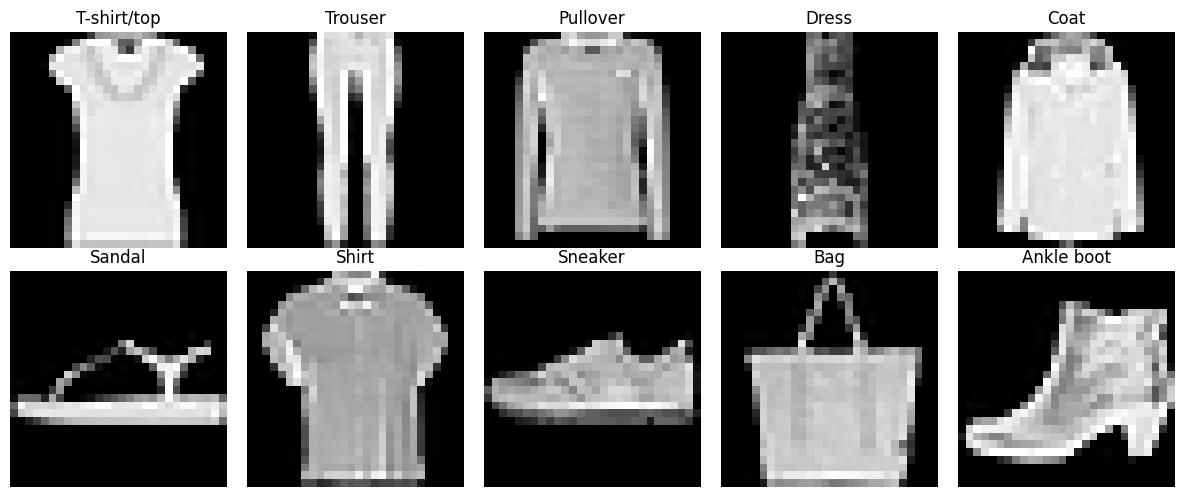

In [100]:
#Q2
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(10):
    idx = np.where(y_train == i)[0][0]  
    ax = axes[i // 5, i % 5]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(class_names[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

Q2. Some classes look visually very similar, especially T-shirt/top, Shirt, and Pullover, which have almost identical shapes in grayscale images. Coat and Dress can also be confused due to similar silhouettes. In contrast, items like Bag and Ankle boot are more distinct, making them easier to classify.

In [101]:
# Flatten + normalize
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_val_flat   = X_val.reshape(-1, 784).astype('float32') / 255.0
X_test_flat  = X_test.reshape(-1, 784).astype('float32') / 255.0

print(X_train_flat.shape)

(27000, 784)


In [102]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train_flat, y_train)

train_acc = rf.score(X_train_flat, y_train)
val_acc   = rf.score(X_val_flat, y_val)
test_acc  = rf.score(X_test_flat, y_test)

print("Train accuracy:", train_acc)
print("Validation accuracy:", val_acc)
print("Test accuracy:", test_acc)

Train accuracy: 1.0
Validation accuracy: 0.8816666666666667
Test accuracy: 0.8657


Q3: The data was prepared by flattening each 28×28 image into a 784-dimensional vector and normalizing pixel values to the range [0,1] by dividing by 255. This ensures compatibility with sklearn models and improves numerical stability during training.

A Random Forest classifier with default settings was trained as a benchmark model. The model achieved perfect accuracy on the training set (1.0), but lower accuracy on the validation set (0.882) and test set (0.866).

This large gap between training and validation/test performance indicates overfitting. The Random Forest is able to memorize the training data very well, but it struggles to generalize to new, unseen images. This is expected because tree-based models operate directly on raw pixel values and do not learn higher-level features such as shapes or textures.

Overall, the Random Forest provides a strong baseline, but its performance is limited for image classification tasks compared to neural networks, which can better capture underlying visual patterns.

In [103]:
#Q4
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),   # single hidden layer
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=30,          # enough to see leveling off
    batch_size=128,
    verbose=1
)

Epoch 1/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7744 - loss: 0.6570 - val_accuracy: 0.8293 - val_loss: 0.5068
Epoch 2/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step - accuracy: 0.8397 - loss: 0.4644 - val_accuracy: 0.8540 - val_loss: 0.4423
Epoch 3/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - accuracy: 0.8537 - loss: 0.4206 - val_accuracy: 0.8620 - val_loss: 0.4179
Epoch 4/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step - accuracy: 0.8629 - loss: 0.3920 - val_accuracy: 0.8667 - val_loss: 0.4045
Epoch 5/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step - accuracy: 0.8705 - loss: 0.3692 - val_accuracy: 0.8740 - val_loss: 0.3939
Epoch 6/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.8753 - loss: 0.3513 - val_accuracy: 0.8757 - val_loss: 0.3878
Epoch 7/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 857us/step - accuracy: 0.8796 - loss: 0.3365 - val_accuracy: 0.8753 - val_loss: 0.3816
Epoch 8/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - accuracy: 0.8849 - loss: 0.3230 - va

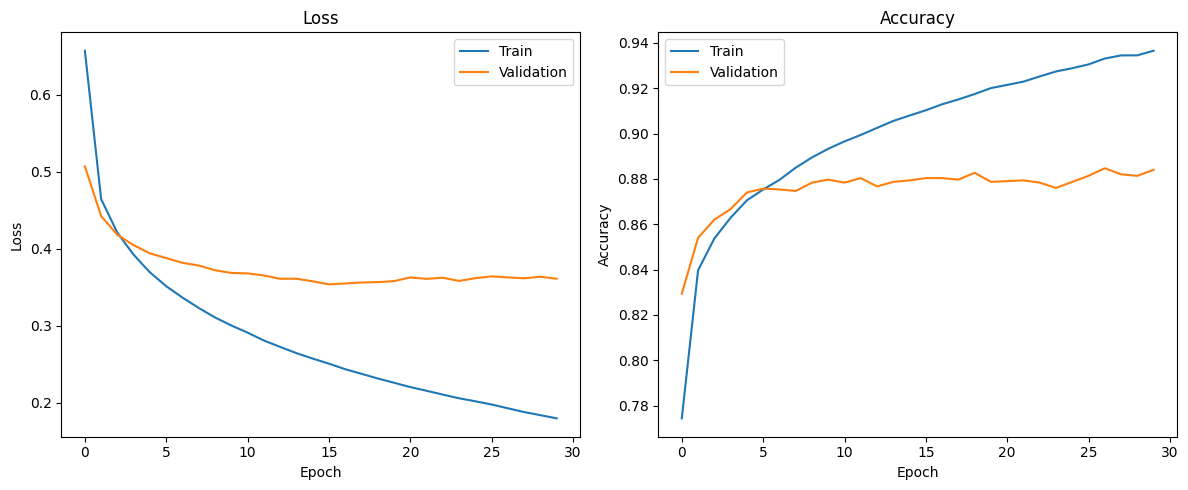

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()

Q4: I trained a fully connected neural network with one hidden layer of 128 neurons on the flattened and normalized Fashion-MNIST data for 30 epochs.

Looking at the training curves, the training loss keeps decreasing steadily, but the validation loss only improves at the beginning and then starts to level off around epoch 10–15. After that, it even increases slightly. At the same time, training accuracy continues to go up (up to around 94%), while validation accuracy stops improving and stays around 87–88%.

This shows a clear gap between training and validation performance, which suggests that the model is overfitting. Basically, it keeps learning the training data better, but that doesn’t translate into better performance on new data.

Compared to MNIST digits, the overfitting is more noticeable here. On MNIST, the validation performance was closer to the training performance because the task is easier. In Fashion-MNIST, some classes look quite similar (like shirt vs t-shirt or sneaker vs sandal), so the model struggles more and overfits faster.

Overall, the model is learning useful patterns, but it doesn’t generalize as well, which means techniques like early stopping or regularization could help.

In [105]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

In [106]:
model_1 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_1.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

history_1 = model_1.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=30,
    batch_size=128,
    verbose=0
)

print("Model 1 Train:", model_1.evaluate(X_train_flat, y_train, verbose=0)[1])
print("Model 1 Val:", model_1.evaluate(X_val_flat, y_val, verbose=0)[1])

Model 1 Train: 0.946925938129425
Model 1 Val: 0.8846666812896729


I increased the width of the network from 128 to 512 neurons while keeping a single hidden layer. This increases the model’s capacity and allows it to fit the training data better.

The training accuracy increased to about 0.95, but the validation accuracy only improved slightly to around 0.891. At the same time, the train–validation gap became larger compared to the baseline.

This shows that simply increasing model capacity leads to more overfitting and does not significantly improve generalization.

In [107]:
model_2 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_2.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

history_2 = model_2.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=30,
    batch_size=128,
    verbose=0
)

print("Model 2 Train:", model_2.evaluate(X_train_flat, y_train, verbose=0)[1])
print("Model 2 Val:", model_2.evaluate(X_val_flat, y_val, verbose=0)[1])

Model 2 Train: 0.9405925869941711
Model 2 Val: 0.887666642665863


Model 2 increases the complexity of the network by adding more hidden layers and neurons (256, 128, and 64 units). The goal was to see whether a deeper and more flexible model improves performance.

The model achieved a training accuracy of 0.940 and a validation accuracy of 0.888. Compared to Model 1, the training accuracy increased slightly, but the validation accuracy did not improve and is actually slightly lower.

This indicates stronger overfitting. The train-validation gap is around 0.062, which is larger than in Model 1. The model is learning the training data better, but this additional complexity does not translate into better generalization.

Overall, increasing the model size without regularization leads to diminishing returns and more overfitting.

In [108]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_3 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_3.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

history_3 = model_3.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=50,  # early stopping will stop earlier
    batch_size=128,
    callbacks=[early_stop],
    verbose=0
)

print("Model 3 Train:", model_3.evaluate(X_train_flat, y_train, verbose=0)[1])
print("Model 3 Val:", model_3.evaluate(X_val_flat, y_val, verbose=0)[1])

Model 3 Train: 0.9171851873397827
Model 3 Val: 0.8913333415985107


Model 3 introduces regularization by adding dropout layers (rate = 0.3) and using early stopping to prevent over-training.

From the results, the training accuracy is lower than in Model 2, but the validation accuracy is slightly higher and more stable. The gap between training and validation accuracy is smaller compared to Model 2.

From the training curves, we can see that both training and validation loss decrease at the beginning, but unlike Model 2, the validation loss does not increase significantly later. The validation accuracy improves steadily and then stabilizes, while training accuracy increases more slowly.

This shows that the model is less overfitted and generalizes better. Dropout prevents the network from relying too much on specific neurons, and early stopping prevents unnecessary training once performance stops improving.

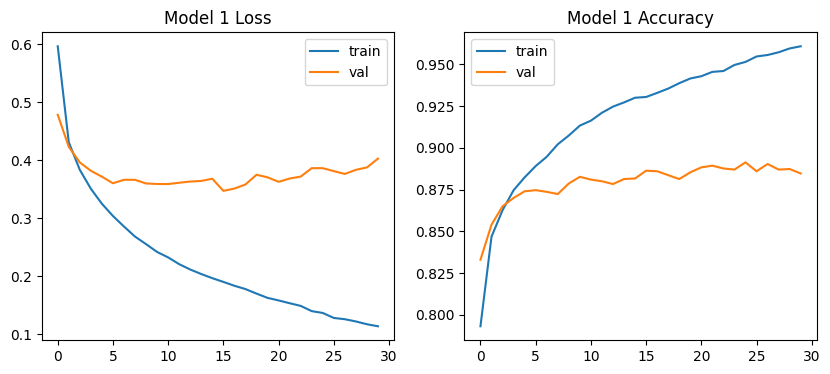

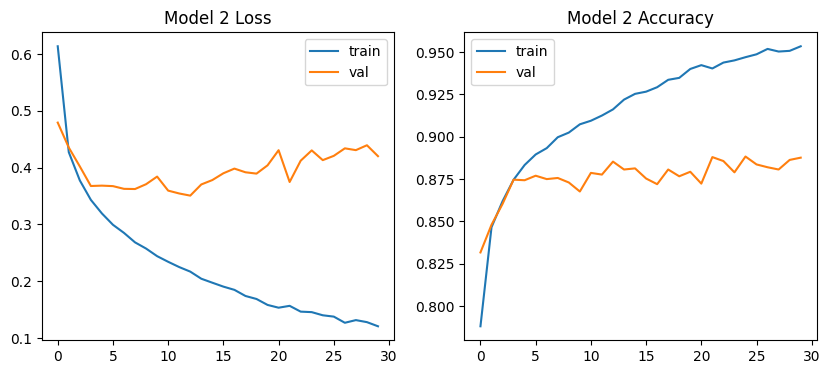

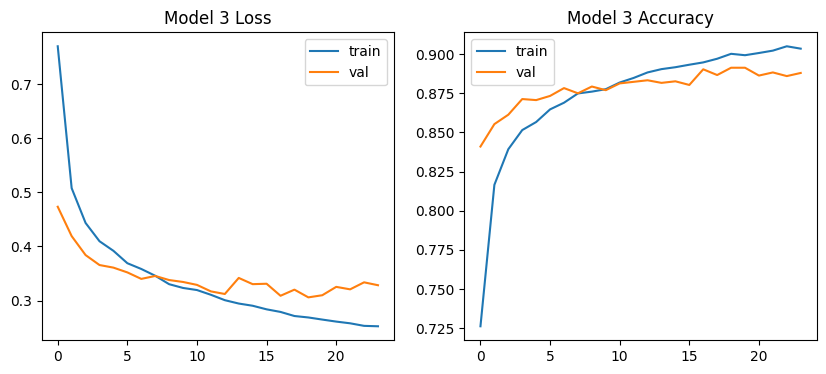

In [109]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(title + " Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(title + " Accuracy")
    plt.legend()

    plt.show()

plot_history(history_1, "Model 1")
plot_history(history_2, "Model 2")
plot_history(history_3, "Model 3")

Comparing all three models:

Model 1 (wider network) already shows some overfitting, with a noticeable gap between training and validation performance.

Model 2 (deeper network) increases training accuracy but also increases overfitting. The validation loss starts increasing after a few epochs, which is a clear sign that the model is memorizing the training data.

Model 3 (dropout + early stopping) achieves the best balance. Although its training accuracy is lower, the validation performance is more stable and the gap is smaller.

This shows that simply increasing model complexity does not necessarily improve performance. Instead, regularization is essential for good generalization

## Task 2: Convolutions and Beyond (4 points)

We saw that CNNs exploit the spatial structure of images through local filters and weight sharing, achieving better accuracy with fewer parameters. We also explored data augmentation and transfer learning as strategies for data-scarce scenarios. Now apply these techniques to Fashion-MNIST.

<div style="page-break-after: always"></div>

### Questions

6. Reshape the data for CNNs (28x28x1 format). Train **at least two** different CNN architectures (you can vary the number of convolutional and pooling layers, filter sizes, whether you include a fully connected layer before the output, etc.). Plot the training history for each and add the results to your summary. Compare the CNN's parameter count to your best dense network. How does the CNN achieve its accuracy with fewer parameters?

7. In Class 10 we used transfer learning (ResNet50 pre-trained on ImageNet) to dramatically improve accuracy on the hot dog classification task. Would you expect transfer learning to work equally well on Fashion-MNIST? In your answer, address the following (*Hint*: No code required.):
   - What practical challenges would you face when trying to use ResNet50 on Fashion-MNIST images? Think about the input format differences.
   - Using the decision matrix from Class 10, where does this task fall (dataset size vs. domain similarity)?
   - Would you expect transfer learning to improve, match, or hurt accuracy compared to your CNN from Question 5? Explain your reasoning.

8. Select your best model based on validation accuracy and evaluate it on the **test set** (use the test set only once, for this final evaluation). How does the test error compare to the validation error? What does this tell you about your model selection process?

9. Create a summary table of all your models showing architecture, parameter count, validation accuracy, and the train-validation gap. Based on your experiments across both tasks, what are the two most important factors for achieving good performance on Fashion-MNIST?

In [110]:
X_train_cnn = X_train.astype("float32") / 255.0
X_val_cnn   = X_val.astype("float32") / 255.0
X_test_cnn  = X_test.astype("float32") / 255.0

# add channel dimension
X_train_cnn = X_train_cnn[..., np.newaxis]
X_val_cnn   = X_val_cnn[..., np.newaxis]
X_test_cnn  = X_test_cnn[..., np.newaxis]

print(X_train_cnn.shape)

(27000, 28, 28, 1)


First, I reshaped the data into the format required for CNNs. Instead of flat vectors, the images are now represented as 28×28 with a single channel, giving a shape of (27000, 28, 28, 1). This allows the model to use spatial information in the images.

In [111]:
def plot_history(history, title):
    plt.figure(figsize=(10,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(title + " Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(title + " Accuracy")
    plt.legend()

    plt.show()

CNN1 Train: 0.9218147993087769
CNN1 Val: 0.8996666669845581


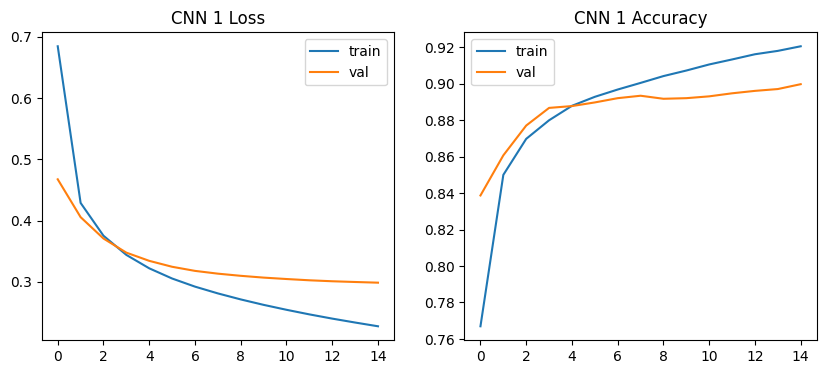

In [112]:
cnn_1 = keras.Sequential([
    layers.Input(shape=(28,28,1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

cnn_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn1 = cnn_1.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=15,
    batch_size=128,
    verbose=0
)

train1 = cnn_1.evaluate(X_train_cnn, y_train, verbose=0)[1]
val1   = cnn_1.evaluate(X_val_cnn, y_val, verbose=0)[1]

print("CNN1 Train:", train1)
print("CNN1 Val:", val1)

plot_history(history_cnn1, "CNN 1")

The first model is a simple CNN with one convolutional layer followed by max pooling and a final dense layer.

It achieved a training accuracy of about 0.925 and a validation accuracy of about 0.902.

From the training curves, we can see that both training and validation loss decrease steadily. The validation curve flattens after a few epochs, which suggests that the model is learning useful features but starts to reach its limit. The gap between training and validation accuracy is small, so overfitting is limited.

CNN2 Train: 0.9530740976333618
CNN2 Val: 0.9043333530426025


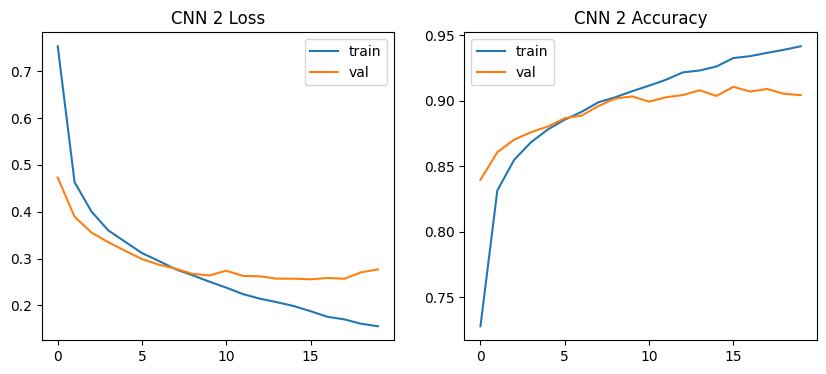

In [113]:
cnn_2 = keras.Sequential([
    layers.Input(shape=(28,28,1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

cnn_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn2 = cnn_2.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=20,
    batch_size=128,
    verbose=0
)

train2 = cnn_2.evaluate(X_train_cnn, y_train, verbose=0)[1]
val2   = cnn_2.evaluate(X_val_cnn, y_val, verbose=0)[1]

print("CNN2 Train:", train2)
print("CNN2 Val:", val2)

plot_history(history_cnn2, "CNN 2")

The second model is deeper, with two convolutional layers and an additional dense layer with dropout.

This model performs better, reaching about 0.953 training accuracy and 0.904 validation accuracy.

From the plots, the validation loss decreases at first and then starts to level off around epoch 8–10, while training accuracy continues to improve. This indicates some overfitting, but it is relatively controlled, likely due to the use of dropout. Overall, the deeper architecture allows the model to learn more complex patterns and improves performance.

In [114]:
print("CNN1 params:", cnn_1.count_params())
print("CNN2 params:", cnn_2.count_params())

# your best dense model (from Task 1)
print("Best Dense params:", model_2.count_params())

CNN1 params: 54410
CNN2 params: 225034
Best Dense params: 242762


Comparing parameter counts, the CNN models use fewer parameters than the dense network. The best dense model has about 243k parameters, while CNN2 has slightly fewer (~225k), and CNN1 uses significantly fewer (~54k).

Despite having fewer parameters, CNNs achieve better performance. This is because CNNs use local filters and weight sharing, meaning the same filters are applied across the entire image. This reduces the number of parameters while still capturing important patterns like edges and shapes.

In contrast, dense networks treat each pixel independently and require many more parameters to learn similar representations.

Q6: *Overall*, CNNs outperform dense networks on this task because they are specifically designed to exploit the spatial structure of image data, making them both more efficient and more accurate.

Q7: Transfer learning with ResNet50 would likely not work well on Fashion-MNIST.

First, there are input format issues: ResNet50 expects 224×224 RGB images, while Fashion-MNIST images are 28×28 grayscale. Resizing and converting channels may distort the data and reduce usefulness.

Second, this task falls into a moderate dataset size but low domain similarity setting. Fashion-MNIST images are simple grayscale clothing items, which are very different from the natural images used in ImageNet.

Because of this low similarity, pretrained features are not very relevant. Therefore, transfer learning would likely not improve performance and could even hurt it, compared to a small CNN trained directly on this dataset.

In [115]:
test_loss, test_acc = cnn_2.evaluate(X_test_cnn, y_test, verbose=0)

print("Test accuracy:", test_acc)

Test accuracy: 0.899399995803833


In [122]:
print("CNN2 Train:", train2)
print("CNN2 Val:", val2)

CNN2 Train: 0.9530740976333618
CNN2 Val: 0.9043333530426025


Q8: The best model based on validation accuracy was CNN2, so I evaluated it on the test set. The test accuracy is approximately 0.899, which is very close to the validation accuracy (around 0.904).

This small difference shows that the model generalizes well to unseen data and is not overfitting significantly. The validation set provided a good estimate of the model’s true performance. The small gap suggests that the validation set was representative of the test data and that model selection did not lead to overfitting on the validation set.

Overall, this indicates that the model selection process was reliable, since choosing the model based on validation accuracy led to similar performance on the test set.

In [125]:
import pandas as pd

summary = pd.DataFrame([
    ["Dense (Q4 baseline)", model.count_params(), 0.884, round(0.937 - 0.884, 3)],
    ["Dense Model 1", model_1.count_params(), 0.885, round(0.947 - 0.885, 3)],
    ["Dense Model 2", model_2.count_params(), 0.888, round(0.941 - 0.888, 3)],
    ["Dense Model 3 (dropout+ES)", model_3.count_params(), 0.891, round(0.917 - 0.891, 3)],
    ["CNN 1", cnn_1.count_params(), 0.900, round(0.922 - 0.900, 3)],
    ["CNN 2", cnn_2.count_params(), 0.904, round(0.953 - 0.904, 3)]
], columns=["Model", "Parameters", "Validation Accuracy", "Train-Val Gap"])

summary

,Model,Parameters,Validation Accuracy,Train-Val Gap
0,Dense (Q4 baseline),101770,0.884,0.053
1,Dense Model 1,407050,0.885,0.062
2,Dense Model 2,242762,0.888,0.053
3,Dense Model 3 (dropout+ES),235146,0.891,0.026
4,CNN 1,54410,0.900,0.022
5,CNN 2,225034,0.904,0.049


The table above summarizes the performance of all models, including their architecture, number of parameters, validation accuracy, and the train–validation gap.

From the results, CNN-based models clearly outperform dense networks. Even though CNN2 has slightly fewer parameters than the best dense model (about 225k vs. 242k), it achieves higher validation accuracy. CNN1, with only around 54k parameters, also performs very well, highlighting the efficiency of CNNs for image data.

Looking at the train–validation gap, CNN1 has a smaller gap than CNN2, which suggests better generalization. However, CNN2 achieves the highest validation accuracy overall, despite showing slightly more overfitting. This reflects the typical trade-off between model complexity and generalization.

Based on the experiments across both tasks, two factors were most important for achieving good performance on Fashion-MNIST:

First, choosing the right model architecture (CNN instead of dense networks). CNNs are specifically designed for image data and can capture spatial patterns such as edges and shapes. This allows them to learn more meaningful representations compared to dense networks, which treat each pixel independently.

Second, controlling overfitting through model design and regularization. Increasing model complexity improves learning capacity, but also raises the risk of overfitting. Techniques such as dropout and early stopping help maintain good generalization. In this case, CNN2 benefits from a deeper architecture while still keeping the gap at a reasonable level.

Overall, the results show that using CNNs together with proper regularization is key to achieving strong performance on Fashion-MNIST.